<a href="https://colab.research.google.com/github/xhavien/CCDATSCL_EXERCISES_COM221ML/blob/main/Exercise5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 5

In [42]:
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats import chi2_contingency


## Part 1: ANOVA

A teacher wants to investigate whether different teaching methods affect students’ exam scores. The dataset contains 50 students, each assigned to one of three teaching methods (A, B, or C).

Question: "Is there a difference in mean exam scores among students taught using three different teaching methods?"

- Independent variable (factor): Teaching Method (A, B, C)
- Dependent variable: Exam Score (numeric)

In [43]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/exam_scores.csv?raw=true"

df_exam_scores = pd.read_csv(url)
df_exam_scores


,StudentID,Method,Score
0,1,A,79
1,2,A,77
2,3,A,82
3,4,A,75
4,5,A,80
5,6,A,78
6,7,A,83
7,8,A,76
8,9,A,81
9,10,A,74


Calculate the number of students in each teaching method.

In [44]:
students_per_method = df_exam_scores['Method'].value_counts()
print("Number of students per teaching method:")
print(students_per_method)

Number of students per teaching method:
Method
A    17
B    17
C    16
Name: count, dtype: int64


Compute the mean and standard deviation of exam scores for each group.

In [45]:
# put your answer here

mean_scores = df_exam_scores.groupby('Method')['Score'].mean()

Use a plot to show the exam scores by teaching method.

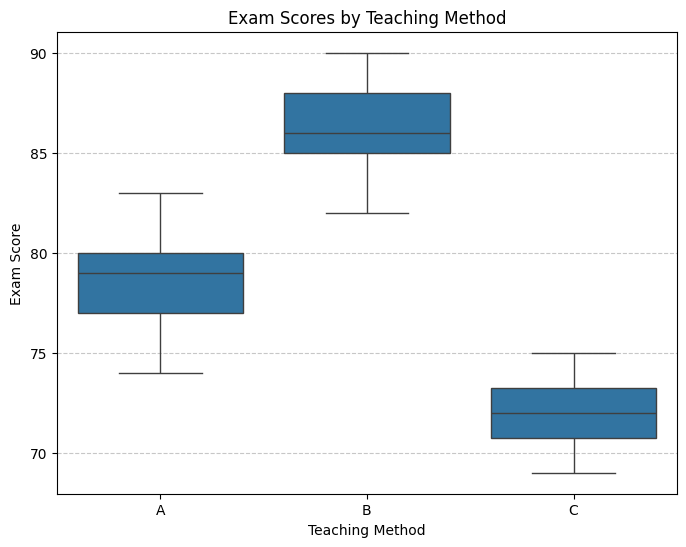

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Method', y='Score', data=df_exam_scores)
plt.title('Exam Scores by Teaching Method')
plt.xlabel('Teaching Method')
plt.ylabel('Exam Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Perform the ANOVA Test
- Use scipy.stats.f_oneway to conduct a one-way ANOVA.
- Report the F-statistic and p-value.
- Using a significance level of α = 0.05, state whether you reject or fail to reject H₀.

In [47]:
group_a = df_exam_scores[df_exam_scores['Method'] == 'A']['Score']
group_b = df_exam_scores[df_exam_scores['Method'] == 'B']['Score']
group_c = df_exam_scores[df_exam_scores['Method'] == 'C']['Score']

f_statistic, p_value = stats.f_oneway(group_a, group_b, group_c)

print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"Since the p-value ({p_value:.4f}) is less than alpha ({alpha}), we reject the null hypothesis.")
else:
    print(f"Since the p-value ({p_value:.4f}) is greater than alpha ({alpha}), we fail to reject the null hypothesis.")

F-statistic: 165.1785
P-value: 0.0000
Since the p-value (0.0000) is less than alpha (0.05), we reject the null hypothesis.


Interpret the results. What does it say about the relationship between teaching method and exam scores?

**INTERPRETATION**:
With a p-value of 0.0000, we reject the null hypothesis. This indicates that teaching methods significantly influence students' exam scores.

## Part 2: Chi-squared

A survey was conducted to see if there is a relationship between gender and littering behavior.

Question:
"Is gender associated with littering behavior?"

Each row represents one person.

In [48]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/litteringdata.csv?raw=true"

df_littering_data = pd.read_csv(url)
df_littering_data

,ID,Gender,Litter
0,1,Male,Yes
1,2,Male,Yes
2,3,Male,Yes
3,4,Male,Yes
4,5,Male,Yes
5,6,Male,Yes
6,7,Male,Yes
7,8,Male,Yes
8,9,Male,Yes
9,10,Male,Yes


Count the number of observations in each category for Gender and Litter separately.

In [49]:
gender_counts = df_littering_data['Gender'].value_counts()
litter_counts = df_littering_data['Litter'].value_counts()

print("Counts for Gender:")
print(gender_counts)
print("\nCounts for Litter:")
print(litter_counts)

Counts for Gender:
Gender
Male      20
Female    20
Name: count, dtype: int64

Counts for Litter:
Litter
No     22
Yes    18
Name: count, dtype: int64


Using `pd.crosstab()`, create a contingency table showing counts of littering behavior for each gender.
- Write down the row totals, column totals, and grand total from the table.

In [50]:
contingency_table = pd.crosstab(df_littering_data['Gender'], df_littering_data['Litter'])
print("Contingency Table:")
print(contingency_table)

row_totals = contingency_table.sum(axis=1)
col_totals = contingency_table.sum(axis=0)
grand_total = contingency_table.sum().sum()

print(f"\nRow Totals:\n{row_totals}")
print(f"\nColumn Totals:\n{col_totals}")
print(f"\nGrand Total: {grand_total}")

Contingency Table:
Litter  No  Yes
Gender         
Female  14    6
Male     8   12

Row Totals:
Gender
Female    20
Male      20
dtype: int64

Column Totals:
Litter
No     22
Yes    18
dtype: int64

Grand Total: 40


State the null hypothesis (H₀) and alternative hypothesis (H₁) for this chi-squared test.

**Null Hypothesis (H₀)**: Gender and littering behavior are independent.

**Alternative Hypothesis (H₁)**: Gender and littering behavior are associated.

Use scipy.stats.chi2_contingency to calculate:
- Chi-squared statistic
- p-value
- Degrees of freedom

Using a significance level of `α = 0.05`, determine whether to reject or fail to reject H₀.


In [51]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom (dof): {dof}")

alpha = 0.05
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.4f}) is less than alpha ({alpha}), we reject the null hypothesis.")
else:
    print(f"\nSince the p-value ({p_value:.4f}) is greater than alpha ({alpha}), we fail to reject the null hypothesis.")

Chi-squared statistic: 2.5253
P-value: 0.1120
Degrees of freedom (dof): 1

Since the p-value (0.1120) is greater than alpha (0.05), we fail to reject the null hypothesis.


Interpret your results. Is there evidence that gender and littering behavior are associated?

**INTERPRETATION:** Since the p-value (0.1120) is greater than alpha (0.05), we fail to reject the null hypothesis.